<a href="https://colab.research.google.com/github/zaibshahzadi/Student-Prediction-Model/blob/main/student_prediction_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Student Prediction Model**

**Import Libraries**

In [ ]:
# Basic Libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# Model Selection
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

# Evaluation
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

**Load Data**

In [ ]:
df = pd.read_csv("student_performance_dataset.csv")

**Data Exploration**

In [ ]:
df.head()

,Student_ID,Gender,Study_Hours_per_Week,Attendance_Rate,Past_Exam_Scores,Parental_Education_Level,Internet_Access_at_Home,Extracurricular_Activities,Final_Exam_Score,Pass_Fail
0,S147,Male,31,68.267841,86,High School,Yes,Yes,63,Pass
1,S136,Male,16,78.222927,73,PhD,No,No,50,Fail
2,S209,Female,21,87.525096,74,PhD,Yes,No,55,Fail
3,S458,Female,27,92.076483,99,Bachelors,No,No,65,Pass
4,S078,Female,37,98.655517,63,Masters,No,Yes,70,Pass


In [ ]:
df.tail()

,Student_ID,Gender,Study_Hours_per_Week,Attendance_Rate,Past_Exam_Scores,Parental_Education_Level,Internet_Access_at_Home,Extracurricular_Activities,Final_Exam_Score,Pass_Fail
703,S492,Male,14,84.658761,78,PhD,Yes,No,50,Fail
704,S301,Male,35,60.278990,83,Masters,No,No,62,Pass
705,S473,Male,25,98.384969,75,Bachelors,Yes,No,57,Fail
706,S307,Female,21,96.148012,84,Bachelors,Yes,No,65,Pass
707,S046,Female,22,80.404392,93,Bachelors,Yes,No,55,Fail


In [ ]:
df.sample(5)

,Student_ID,Gender,Study_Hours_per_Week,Attendance_Rate,Past_Exam_Scores,Parental_Education_Level,Internet_Access_at_Home,Extracurricular_Activities,Final_Exam_Score,Pass_Fail
300,S069,Female,35,73.005958,74,PhD,No,Yes,60,Pass
14,S141,Female,12,62.217658,62,Masters,Yes,No,50,Fail
549,S378,Male,28,66.199503,58,High School,Yes,Yes,53,Fail
23,S384,Male,27,93.822204,57,High School,Yes,No,57,Fail
601,S062,Male,28,52.293063,78,PhD,Yes,No,50,Fail


In [ ]:
print("Rows and Columns :", df.shape)

Rows and Columns : (708, 10)


In [ ]:
df.columns

Index(['Student_ID', 'Gender', 'Study_Hours_per_Week', 'Attendance_Rate',
       'Past_Exam_Scores', 'Parental_Education_Level',
       'Internet_Access_at_Home', 'Extracurricular_Activities',
       'Final_Exam_Score', 'Pass_Fail'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 708 entries, 0 to 707
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  708 non-null    object 
 1   Gender                      708 non-null    object 
 2   Study_Hours_per_Week        708 non-null    int64  
 3   Attendance_Rate             708 non-null    float64
 4   Past_Exam_Scores            708 non-null    int64  
 5   Parental_Education_Level    708 non-null    object 
 6   Internet_Access_at_Home     708 non-null    object 
 7   Extracurricular_Activities  708 non-null    object 
 8   Final_Exam_Score            708 non-null    int64  
 9   Pass_Fail                   708 non-null    object 
dtypes: float64(1), int64(3), object(6)
memory usage: 55.4+ KB


In [ ]:
df.dtypes

,0
Student_ID,object
Gender,object
Study_Hours_per_Week,int64
Attendance_Rate,float64
Past_Exam_Scores,int64
Parental_Education_Level,object
Internet_Access_at_Home,object
Extracurricular_Activities,object
Final_Exam_Score,int64
Pass_Fail,object


In [ ]:
df.describe()

,Study_Hours_per_Week,Attendance_Rate,Past_Exam_Scores,Final_Exam_Score
count,708.000000,708.000000,708.000000,708.000000
mean,26.132768,78.107722,77.871469,58.771186
std,8.877727,13.802802,14.402739,6.705877
min,10.000000,50.116970,50.000000,50.000000
25%,19.000000,67.550094,65.000000,52.000000
50%,27.000000,79.363046,79.000000,59.500000
75%,34.000000,89.504232,91.000000,64.000000
max,39.000000,99.967675,100.000000,77.000000


In [ ]:
df.isnull().sum()

,0
Student_ID,0
Gender,0
Study_Hours_per_Week,0
Attendance_Rate,0
Past_Exam_Scores,0
Parental_Education_Level,0
Internet_Access_at_Home,0
Extracurricular_Activities,0
Final_Exam_Score,0
Pass_Fail,0


In [ ]:
df.duplicated().sum()

np.int64(208)

In [ ]:
for col in df.columns:
    print(col)
    print(df[col].unique())
    print("-"*50)

Student_ID
['S147' 'S136' 'S209' 'S458' 'S078' 'S417' 'S302' 'S009' 'S044' 'S331'
 'S451' 'S059' 'S315' 'S295' 'S141' 'S274' 'S327' 'S413' 'S452' 'S386'
 'S079' 'S375' 'S384' 'S207' 'S071' 'S489' 'S066' 'S018' 'S015' 'S155'
 'S159' 'S368' 'S104' 'S329' 'S397' 'S097' 'S112' 'S370' 'S463' 'S060'
 'S041' 'S216' 'S430' 'S377' 'S187' 'S233' 'S166' 'S419' 'S033' 'S185'
 'S057' 'S372' 'S395' 'S211' 'S361' 'S382' 'S389' 'S387' 'S380' 'S020'
 'S445' 'S099' 'S448' 'S408' 'S089' 'S049' 'S194' 'S121' 'S362' 'S322'
 'S499' 'S251' 'S314' 'S200' 'S399' 'S072' 'S162' 'S440' 'S139' 'S449'
 'S108' 'S476' 'S068' 'S178' 'S406' 'S340' 'S379' 'S246' 'S164' 'S008'
 'S051' 'S142' 'S394' 'S045' 'S013' 'S085' 'S300' 'S438' 'S439' 'S012'
 'S366' 'S180' 'S486' 'S431' 'S160' 'S353' 'S265' 'S152' 'S259' 'S429'
 'S014' 'S482' 'S297' 'S055' 'S280' 'S034' 'S494' 'S163' 'S433' 'S028'
 'S328' 'S355' 'S225' 'S213' 'S435' 'S271' 'S365' 'S186' 'S284' 'S019'
 'S143' 'S299' 'S090' 'S214' 'S369' 'S402' 'S344' 'S480' 'S279' 'S

In [ ]:
df["Pass_Fail"].value_counts(normalize=True)*100

,proportion
Pass_Fail,
Pass,50.0
Fail,50.0


**Visualization / EDA (Exploratory Data Analysis)**

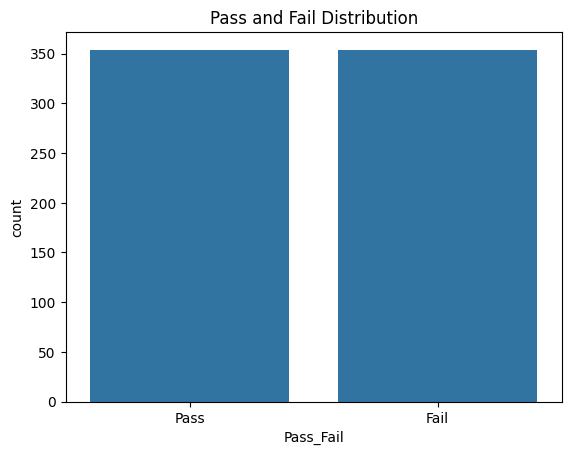

In [ ]:
sns.countplot(x="Pass_Fail", data=df)
plt.title("Pass and Fail Distribution")
plt.show()

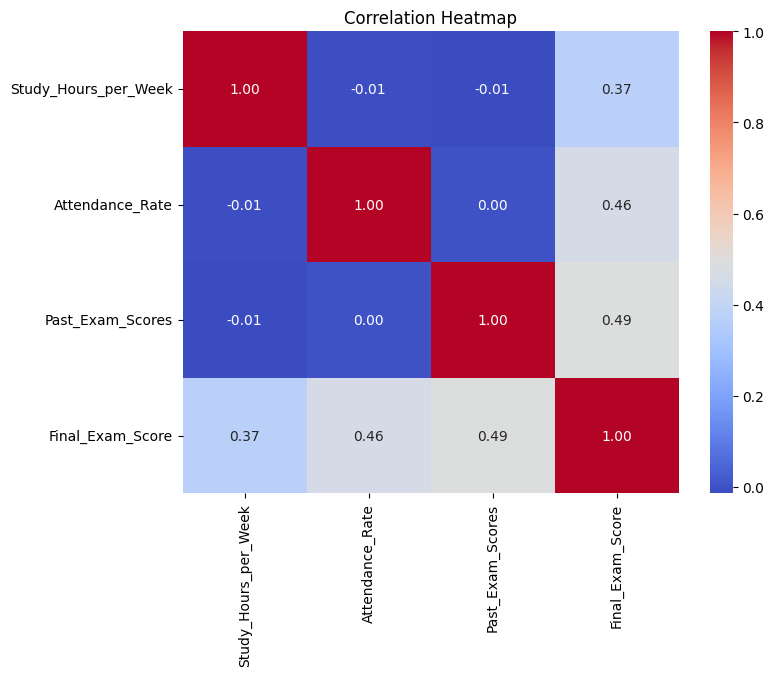

In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

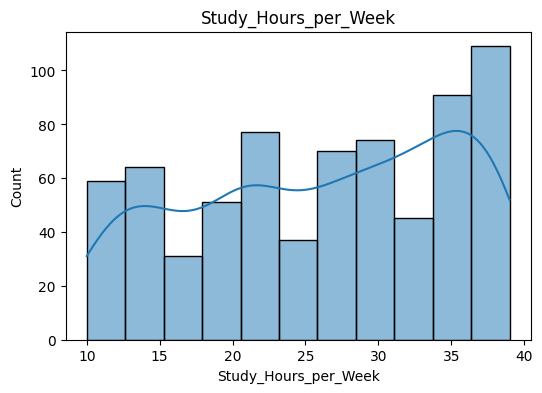

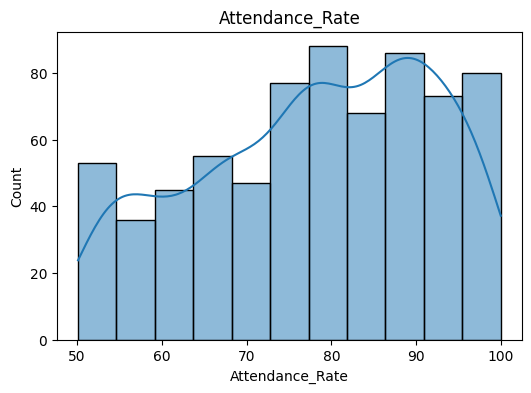

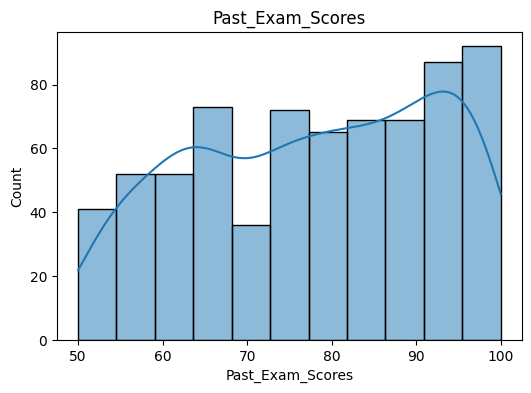

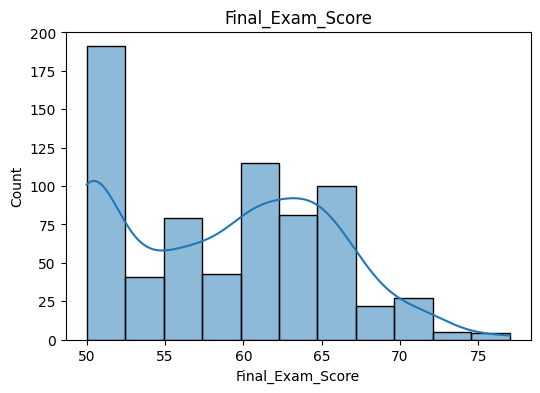

In [ ]:
numerical_columns = [
    "Study_Hours_per_Week",
    "Attendance_Rate",
    "Past_Exam_Scores",
    "Final_Exam_Score"
]

for col in numerical_columns:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

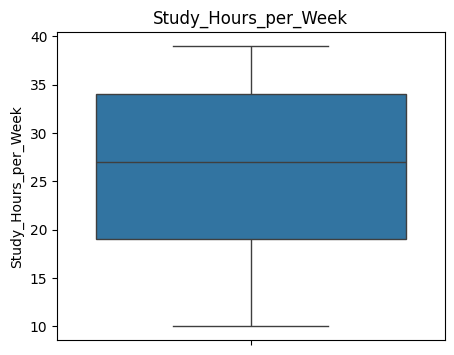

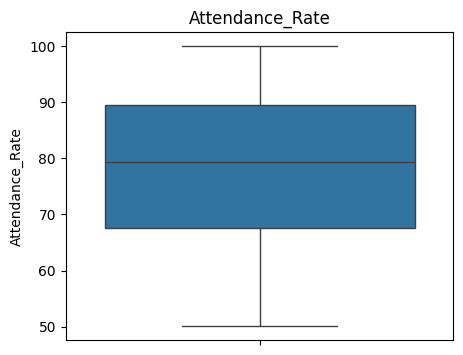

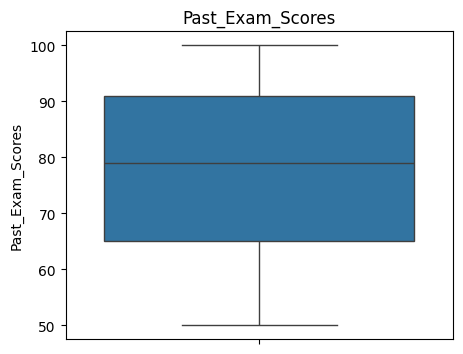

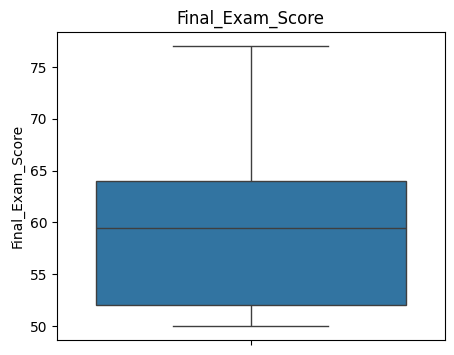

In [ ]:
for col in numerical_columns:
    plt.figure(figsize=(5,4))
    sns.boxplot(y=df[col])
    plt.title(col)
    plt.show()

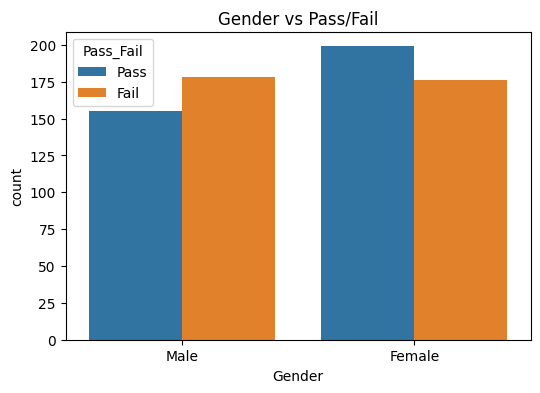

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="Gender",
    hue="Pass_Fail",
    data=df
)

plt.title("Gender vs Pass/Fail")

plt.show()

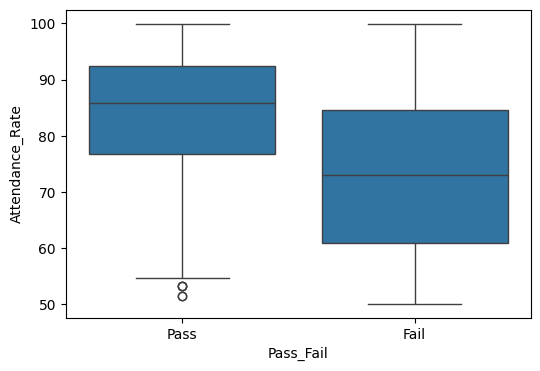

In [ ]:
plt.figure(figsize=(6,4))

sns.boxplot(
    x="Pass_Fail",
    y="Attendance_Rate",
    data=df
)

plt.show()

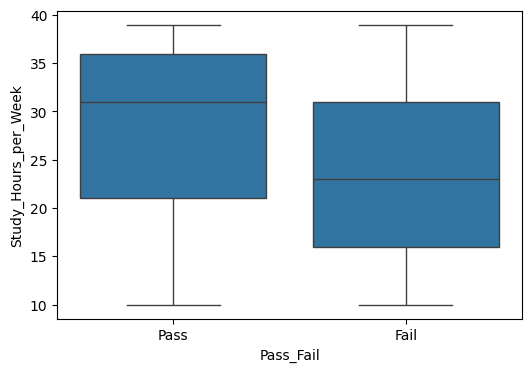

In [ ]:
plt.figure(figsize=(6,4))

sns.boxplot(
    x="Pass_Fail",
    y="Study_Hours_per_Week",
    data=df
)

plt.show()

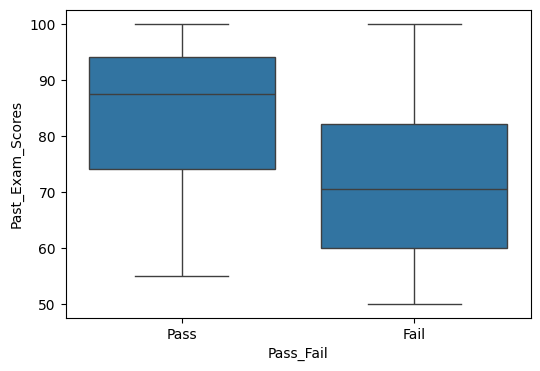

In [ ]:
plt.figure(figsize=(6,4))

sns.boxplot(
    x="Pass_Fail",
    y="Past_Exam_Scores",
    data=df
)

plt.show()

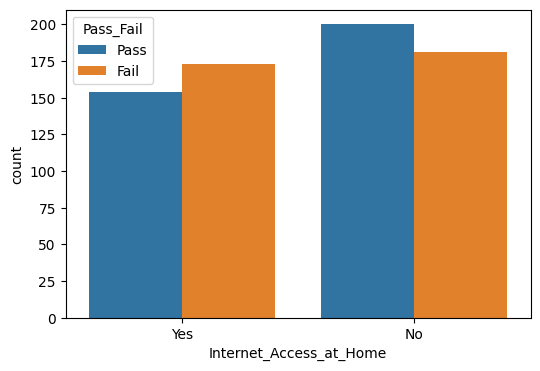

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="Internet_Access_at_Home",
    hue="Pass_Fail",
    data=df
)

plt.show()

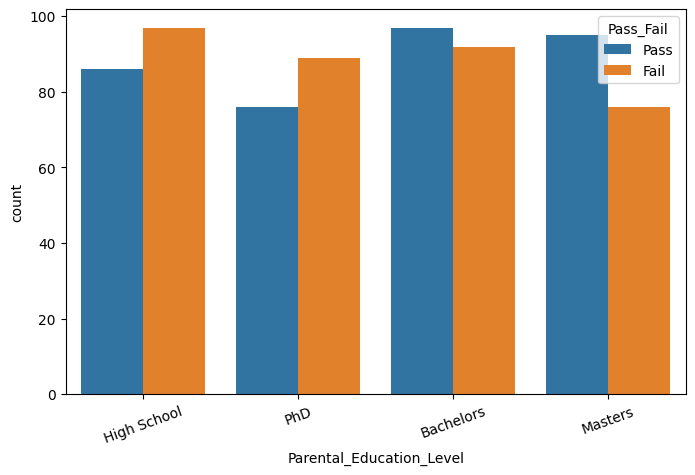

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="Parental_Education_Level",
    hue="Pass_Fail",
    data=df
)

plt.xticks(rotation=20)

plt.show()

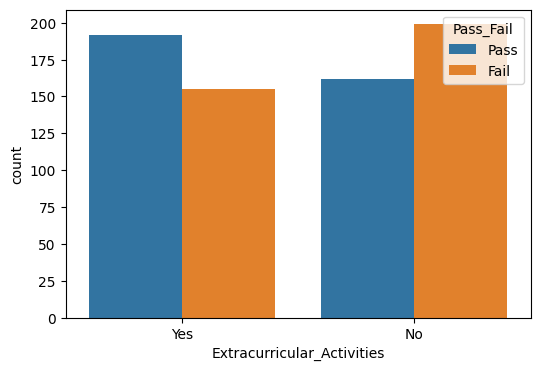

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="Extracurricular_Activities",
    hue="Pass_Fail",
    data=df
)

plt.show()

**Data Preprocessing**

In [ ]:
df.drop("Student_ID", axis=1, inplace=True)

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_columns = df.select_dtypes(include="object").columns

for col in categorical_columns:
    df[col] = le.fit_transform(df[col])

df.head()

,Gender,Study_Hours_per_Week,Attendance_Rate,Past_Exam_Scores,Parental_Education_Level,Internet_Access_at_Home,Extracurricular_Activities,Final_Exam_Score,Pass_Fail
0,1,31,68.267841,86,1,1,1,63,1
1,1,16,78.222927,73,3,0,0,50,0
2,0,21,87.525096,74,3,1,0,55,0
3,0,27,92.076483,99,0,0,0,65,1
4,0,37,98.655517,63,2,0,1,70,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 708 entries, 0 to 707
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Gender                      708 non-null    int64  
 1   Study_Hours_per_Week        708 non-null    int64  
 2   Attendance_Rate             708 non-null    float64
 3   Past_Exam_Scores            708 non-null    int64  
 4   Parental_Education_Level    708 non-null    int64  
 5   Internet_Access_at_Home     708 non-null    int64  
 6   Extracurricular_Activities  708 non-null    int64  
 7   Final_Exam_Score            708 non-null    int64  
 8   Pass_Fail                   708 non-null    int64  
dtypes: float64(1), int64(8)
memory usage: 49.9 KB


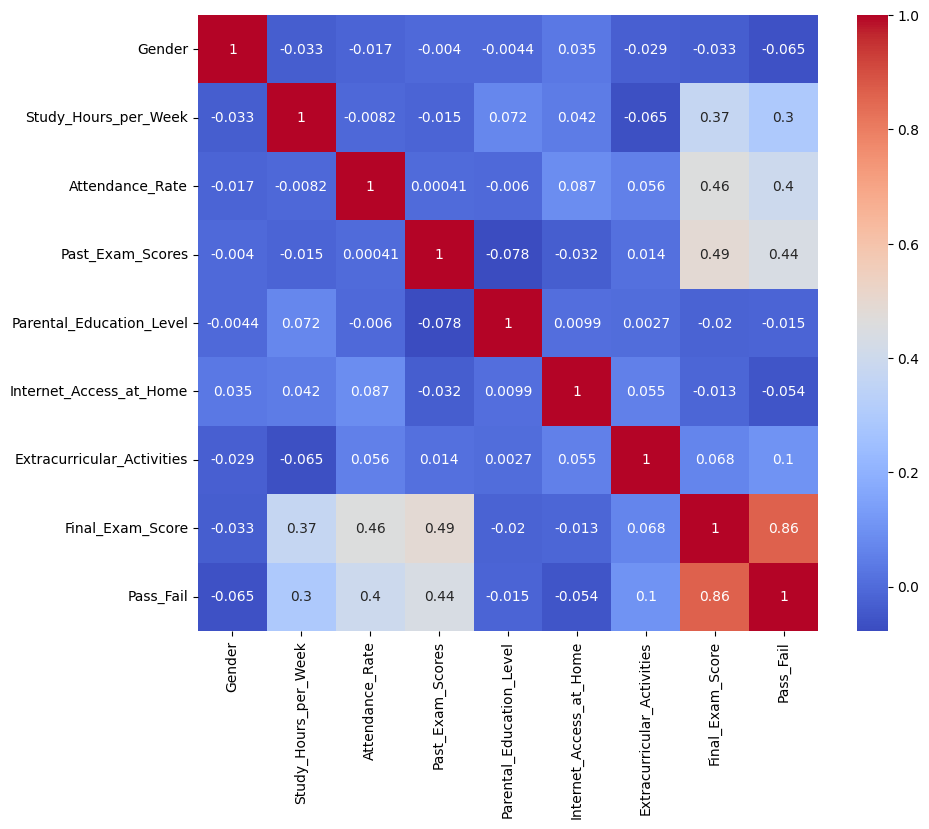

In [ ]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

In [ ]:
X = df.drop(["Pass_Fail", "Final_Exam_Score"], axis=1)

y = df["Pass_Fail"]

In [ ]:
print(X.head())
print(y.head())

   Gender  Study_Hours_per_Week  Attendance_Rate  Past_Exam_Scores  \
0       1                    31        68.267841                86   
1       1                    16        78.222927                73   
2       0                    21        87.525096                74   
3       0                    27        92.076483                99   
4       0                    37        98.655517                63   

   Parental_Education_Level  Internet_Access_at_Home  \
0                         1                        1   
1                         3                        0   
2                         3                        1   
3                         0                        0   
4                         2                        0   

   Extracurricular_Activities  
0                           1  
1                           0  
2                           0  
3                           0  
4                           1  
0    1
1    0
2    0
3    1
4    1
Name: Pass_Fail

**Train-Test Split**

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Data :", X_train.shape)
print("Testing Data :", X_test.shape)

Training Data : (566, 7)
Testing Data : (142, 7)


**Feature Scaling**

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Models Training**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

lr = LogisticRegression(random_state=42)

lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)

print("Accuracy :", accuracy_score(y_test, lr_pred))

print("\nClassification Report\n")
print(classification_report(y_test, lr_pred))

Accuracy : 0.7816901408450704

Classification Report

              precision    recall  f1-score   support

           0       0.79      0.76      0.78        71
           1       0.77      0.80      0.79        71

    accuracy                           0.78       142
   macro avg       0.78      0.78      0.78       142
weighted avg       0.78      0.78      0.78       142



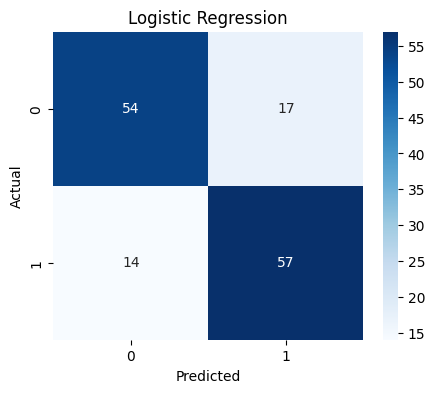

In [ ]:
cm = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression")
plt.show()

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

knn_pred = knn.predict(X_test_scaled)

print("Accuracy :", accuracy_score(y_test, knn_pred))

print(classification_report(y_test, knn_pred))

Accuracy : 0.8028169014084507
              precision    recall  f1-score   support

           0       0.83      0.76      0.79        71
           1       0.78      0.85      0.81        71

    accuracy                           0.80       142
   macro avg       0.80      0.80      0.80       142
weighted avg       0.80      0.80      0.80       142



In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("Accuracy :", accuracy_score(y_test, dt_pred))

print(classification_report(y_test, dt_pred))

Accuracy : 0.8450704225352113
              precision    recall  f1-score   support

           0       0.90      0.77      0.83        71
           1       0.80      0.92      0.86        71

    accuracy                           0.85       142
   macro avg       0.85      0.85      0.84       142
weighted avg       0.85      0.85      0.84       142



In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Accuracy :", accuracy_score(y_test, rf_pred))

print(classification_report(y_test, rf_pred))

Accuracy : 0.8802816901408451
              precision    recall  f1-score   support

           0       0.95      0.80      0.87        71
           1       0.83      0.96      0.89        71

    accuracy                           0.88       142
   macro avg       0.89      0.88      0.88       142
weighted avg       0.89      0.88      0.88       142



In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

svm = SVC(random_state=42)

svm.fit(X_train_scaled, y_train)

svm_pred = svm.predict(X_test_scaled)

print("Accuracy :", accuracy_score(y_test, svm_pred))

print(classification_report(y_test, svm_pred))

Accuracy : 0.795774647887324
              precision    recall  f1-score   support

           0       0.84      0.73      0.78        71
           1       0.76      0.86      0.81        71

    accuracy                           0.80       142
   macro avg       0.80      0.80      0.79       142
weighted avg       0.80      0.80      0.79       142



In [ ]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()

nb.fit(X_train, y_train)

nb_pred = nb.predict(X_test)

print("Accuracy :", accuracy_score(y_test, nb_pred))

print(classification_report(y_test, nb_pred))

Accuracy : 0.7746478873239436
              precision    recall  f1-score   support

           0       0.81      0.72      0.76        71
           1       0.75      0.83      0.79        71

    accuracy                           0.77       142
   macro avg       0.78      0.77      0.77       142
weighted avg       0.78      0.77      0.77       142



In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(random_state=42)

gb.fit(X_train, y_train)

gb_pred = gb.predict(X_test)

print("Accuracy :", accuracy_score(y_test, gb_pred))

print(classification_report(y_test, gb_pred))

Accuracy : 0.8661971830985915
              precision    recall  f1-score   support

           0       0.96      0.76      0.85        71
           1       0.80      0.97      0.88        71

    accuracy                           0.87       142
   macro avg       0.88      0.87      0.86       142
weighted avg       0.88      0.87      0.86       142



In [ ]:
pip install xgboost

In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

print("Accuracy :", accuracy_score(y_test, xgb_pred))

print(classification_report(y_test, xgb_pred))

Accuracy : 0.8661971830985915
              precision    recall  f1-score   support

           0       0.95      0.77      0.85        71
           1       0.81      0.96      0.88        71

    accuracy                           0.87       142
   macro avg       0.88      0.87      0.87       142
weighted avg       0.88      0.87      0.87       142



**Hyperparameter Tuning**

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

grid_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

print("Best Parameters:")
print(grid_rf.best_params_)

best_rf = grid_rf.best_estimator_

best_pred = best_rf.predict(X_test)

print("\nAccuracy:", accuracy_score(y_test, best_pred))

Best Parameters:
{'criterion': 'gini', 'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}

Accuracy: 0.8802816901408451


**Cross Validation**

In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    best_rf,
    X,
    y,
    cv=5,
    scoring='accuracy'
)

print("Cross Validation Scores:")
print(scores)

print("\nAverage Accuracy:")
print(scores.mean())

Cross Validation Scores:
[0.83802817 0.9084507  0.90140845 0.92198582 0.90070922]

Average Accuracy:
0.8941164718809309


**Feature Importance**

In [ ]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_rf.feature_importances_
})

importance = importance.sort_values(by='Importance', ascending=False)

print(importance)

                      Feature  Importance
3            Past_Exam_Scores    0.322137
2             Attendance_Rate    0.314884
1        Study_Hours_per_Week    0.221406
4    Parental_Education_Level    0.058081
0                      Gender    0.029516
6  Extracurricular_Activities    0.027790
5     Internet_Access_at_Home    0.026186


**SHAP Value Analysis**

In [ ]:
pip install shap

In [ ]:
import shap

# TreeExplainer works directly with tree-based models like RandomForest
explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_test)

# SHAP API differs slightly across versions:
# - older versions return a list [class0_values, class1_values]
# - newer versions return a single array of shape (n_samples, n_features, n_classes)
if isinstance(shap_values, list):
    shap_values_pass = shap_values[1]   # contributions toward class 1 = Pass
else:
    shap_values_pass = shap_values[:, :, 1]

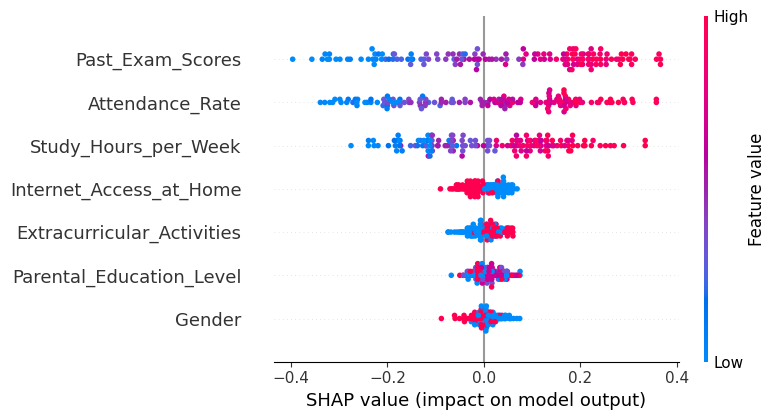

In [ ]:
# Summary plot: shows direction (color) and magnitude of each feature's impact
shap.summary_plot(shap_values_pass, X_test)

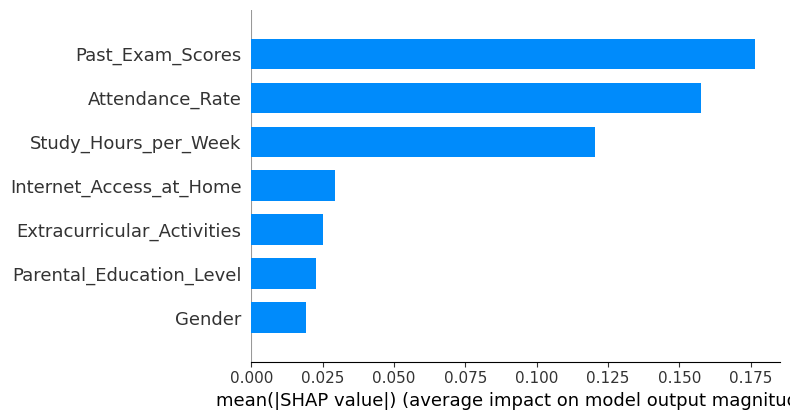

In [ ]:
# Bar plot: global feature importance according to SHAP (mean absolute impact)
shap.summary_plot(shap_values_pass, X_test, plot_type="bar")

**Model Comparison**

In [ ]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "KNN",
        "Decision Tree",
        "Random Forest",
        "SVM",
        "Naive Bayes",
        "Gradient Boosting",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, knn_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, svm_pred),
        accuracy_score(y_test, nb_pred),
        accuracy_score(y_test, gb_pred),
        accuracy_score(y_test, xgb_pred)
    ]
})

results = results.sort_values(by="Accuracy", ascending=False)

print(results)

                 Model  Accuracy
3        Random Forest  0.880282
7              XGBoost  0.866197
6    Gradient Boosting  0.866197
2        Decision Tree  0.845070
1                  KNN  0.802817
4                  SVM  0.795775
0  Logistic Regression  0.781690
5          Naive Bayes  0.774648


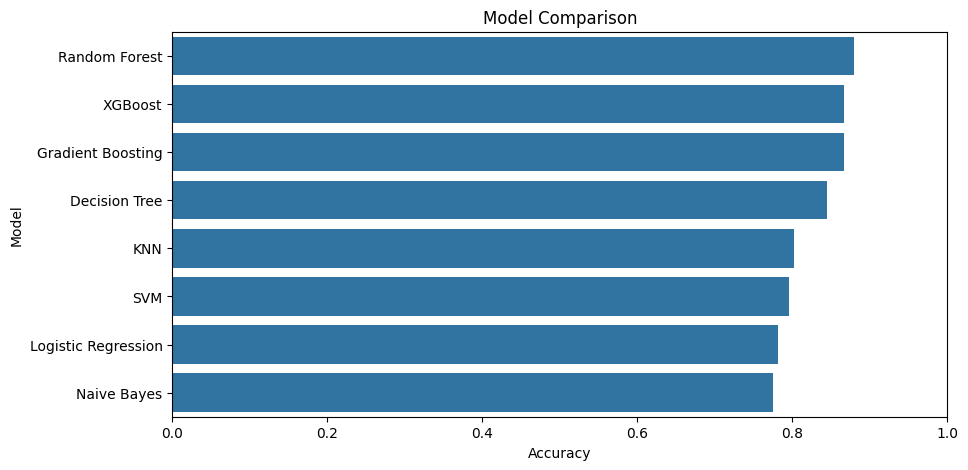

In [ ]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=results,
    x="Accuracy",
    y="Model"
)

plt.title("Model Comparison")
plt.xlim(0, 1)
plt.show()

**Final Evaluation**

In [ ]:
best_model = results.loc[results["Accuracy"].idxmax()]

print("========== Best Model ==========")
print(best_model)

========== Best Model ==========
Model       Random Forest
Accuracy         0.880282
Name: 3, dtype: object


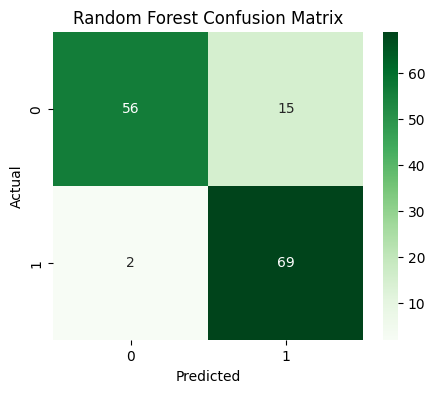

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")

plt.show()

In [ ]:
from sklearn.metrics import roc_curve, auc

y_prob = best_rf.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()

**Model Save**

In [ ]:
import joblib

joblib.dump(best_rf,"student_prediction_model.pkl")

print("Model Saved Successfully")

**Test in New Student**

In [ ]:
new_student = pd.DataFrame({
    'Gender': [1],
    'Study_Hours_per_Week': [10],
    'Attendance_Rate': [80],
    'Past_Exam_Scores': [75],
    'Parental_Education_Level': [2],
    'Internet_Access_at_Home': [1],
    'Extracurricular_Activities': [1]
})

In [ ]:
# Prediction
prediction = best_rf.predict(new_student)

# Confidence Score
probability = best_rf.predict_proba(new_student)
confidence = np.max(probability) * 100

print("="*50)
print("STUDENT PERFORMANCE PREDICTION")
print("="*50)

if prediction[0] == 1:
    print("✅ Prediction : PASS")
else:
    print("❌ Prediction : FAIL")

print(f"Model Confidence : {confidence:.2f}%")

STUDENT PERFORMANCE PREDICTION
❌ Prediction : FAIL
Model Confidence : 69.00%


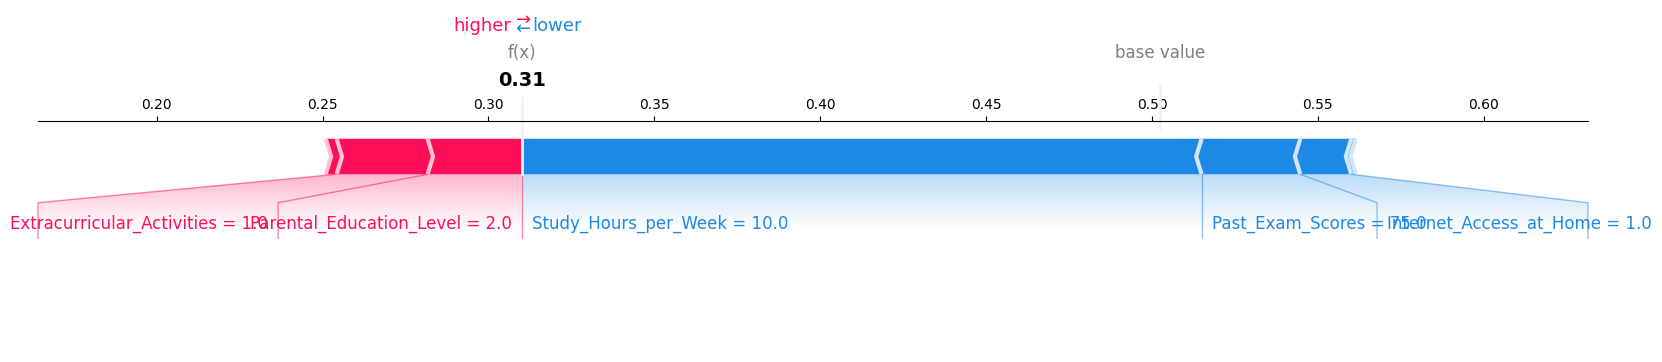

In [ ]:
# SHAP explanation for THIS specific student's prediction
student_shap = explainer.shap_values(new_student)

if isinstance(student_shap, list):
    student_shap_pass = student_shap[1][0]
    base_value_pass = explainer.expected_value[1]
else:
    student_shap_pass = student_shap[0, :, 1]
    base_value_pass = explainer.expected_value[1] if hasattr(explainer.expected_value, "__len__") else explainer.expected_value

# Force plot: shows which features pushed this student toward PASS (red) or FAIL (blue)
shap.initjs()
shap.force_plot(
    base_value_pass,
    student_shap_pass,
    new_student,
    matplotlib=True
)

In [ ]:
# Personalized Improvement Suggestions - driven by SHAP values (not fixed thresholds)
# Idea: for THIS student, find which features pushed the prediction most toward FAIL,
# and give advice only for those features (so every student gets a suggestion list
# that matches their own weak points, not a generic checklist).

if prediction[0] == 1:
    print("🎉 Prediction: Student will PASS")
    print("\nExcellent Performance! Keep up the good habits.")

else:
    print(" Prediction: Student will FAIL")
    print("\nPersonalized Improvement Suggestions:\n")

    contributions = pd.DataFrame({
        "Feature": new_student.columns,
        "SHAP_Value": student_shap_pass   # negative = pushed the student toward FAIL
    }).sort_values(by="SHAP_Value")

    # Take the features that hurt this student's PASS chances the most
    risk_factors = contributions[contributions["SHAP_Value"] < 0].head(3)

    # If nothing is technically negative (rare edge case), just take the weakest 3
    if risk_factors.empty:
        risk_factors = contributions.head(3)

    suggestion_map = {
        "Study_Hours_per_Week": "Increase study hours — aim for at least 15-20 hours per week.",
        "Attendance_Rate": "Improve attendance — try to stay consistently above 80%.",
        "Past_Exam_Scores": "Past exam scores are a weak point — revise fundamentals and take extra practice tests.",
        "Internet_Access_at_Home": "Limited internet access may be limiting resources — look into offline materials or library/lab access.",
        "Extracurricular_Activities": "Re-balance time between extracurriculars and academics.",
        "Parental_Education_Level": "Consider extra academic support such as tutoring or study groups.",
        "Gender": None  # not an actionable feature, skip
    }

    for _, row in risk_factors.iterrows():
        feature = row["Feature"]
        tip = suggestion_map.get(feature)
        if tip:
            print(f" - {feature} (SHAP impact: {row['SHAP_Value']:.3f}) → {tip}")

 Prediction: Student will FAIL

Personalized Improvement Suggestions:

 - Study_Hours_per_Week (SHAP impact: -0.205) → Increase study hours — aim for at least 15-20 hours per week.
 - Past_Exam_Scores (SHAP impact: -0.030) → Past exam scores are a weak point — revise fundamentals and take extra practice tests.
 - Internet_Access_at_Home (SHAP impact: -0.015) → Limited internet access may be limiting resources — look into offline materials or library/lab access.
